In [1]:
import scvelo as scv
import scanpy as sc
import pandas as pd
import numpy as np
import pickle

scv.settings.set_figure_params('scvelo')

import matplotlib.colors as mcolors
color_plate = list(mcolors.TABLEAU_COLORS)

In [2]:
import os, sys
os.chdir("/mnt/yijun/nfs_share/awa_project/pairsRegulatePrediction/GPLVM_dandan/")

In [3]:
### option 1: calculate RNA velocity from the beginning.
adata = sc.read("data/240108mouse_embryogenesis/blood_exp.mtx", cache=True)
spliced = sc.read("data/240108mouse_embryogenesis/blood_exp_exon.mtx", cache=True)
unspliced = sc.read("data/240108mouse_embryogenesis/blood_exp_intron.mtx", cache=True)
pdata = pd.read_csv("data/240108mouse_embryogenesis/blood_obs.csv", index_col = 0)
fdata = pd.read_csv("data/240108mouse_embryogenesis/blood_var.csv", index_col = 0)

### add spliced and unspliced to layers, pd to obs
adata.layers['spliced'] = spliced.X
adata.layers['unspliced'] = unspliced.X
adata.obs = pdata
adata.var = fdata
scv.utils.show_proportions(adata)

Abundance of ['unspliced', 'spliced']: [0.62 0.38]


In [4]:
print("Import data, cell number: {}, gene number: {}".format(adata.n_obs, adata.n_vars))
print("Annotation information of data includes: {}".format(adata.obs_keys()))  # 胞注釋信息的keys
print("Cell id first 5: {}".format(adata.obs_names[:5]))  # 返回胞ID 数据类型是object
print("Gene id first 5: {}".format(adata.var_names[:5]))  # 返回基因数据类型是list adata.obs.head()# 査看前5行的数据
print(adata.obs.celltype.value_counts())
print(adata.obs.day.value_counts())
print(adata.X)
print(adata.obs)

Import data, cell number: 53268, gene number: 24552
Annotation information of data includes: ['Anno', 'day', 'celltype', 'sample', 'batch', 'group']
Cell id first 5: Index(['P2-01A.ATGGTAACTTAGCCGGTACC', 'P2-01A.AACGAGCGTCCGTTCGGAT',
       'P2-01A.CCGTCGATTCTTGCAACCT', 'P2-01A.ATTGAGGAATTTATTCTGAG',
       'P2-01A.ATTCGGAGTTATAGACGCA'],
      dtype='object')
Gene id first 5: Index(['ENSMUSG00000051951', 'ENSMUSG00000102343', 'ENSMUSG00000025900',
       'ENSMUSG00000025902', 'ENSMUSG00000104328'],
      dtype='object')
celltype
Definitive erythroid cells    22038
Primitive erythroid cells     21309
White blood cells              8213
Megakaryocytes                 1509
Blood progenitors               199
Name: count, dtype: int64
day
E11.5    14930
E13.5    13673
E10.5     9308
E12.5     9090
E9.5      3390
E8.5b     2877
Name: count, dtype: int64
  (0, 8)	1.0
  (0, 25)	1.0
  (0, 26)	2.0
  (0, 28)	1.0
  (0, 31)	1.0
  (0, 32)	1.0
  (0, 33)	2.0
  (0, 55)	1.0
  (0, 56)	1.0
  (0, 122)	1.0

In [5]:
global_file_path = "/mnt/yijun/nfs_share/awa_project/pairsRegulatePrediction/GPLVM_dandan/data/mouse_embryonic_development/"
gene_list_atlas = pd.read_csv("{}/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/gene_info.csv".format(global_file_path), index_col=0,sep='\t')
gene_list_atlas['gene_id']

ENSMUSG00000002459    ENSMUSG00000002459
ENSMUSG00000033740    ENSMUSG00000033740
ENSMUSG00000025909    ENSMUSG00000025909
ENSMUSG00000025915    ENSMUSG00000025915
ENSMUSG00000046101    ENSMUSG00000046101
                             ...        
ENSMUSG00000063434    ENSMUSG00000063434
ENSMUSG00000043531    ENSMUSG00000043531
ENSMUSG00000035804    ENSMUSG00000035804
ENSMUSG00000043639    ENSMUSG00000043639
ENSMUSG00000025089    ENSMUSG00000025089
Name: gene_id, Length: 979, dtype: object

In [6]:
adata=adata[:,gene_list_atlas['gene_id']]
adata

View of AnnData object with n_obs × n_vars = 53268 × 979
    obs: 'Anno', 'day', 'celltype', 'sample', 'batch', 'group'
    var: 'gene_id', 'gene_short_name'
    layers: 'spliced', 'unspliced'

In [7]:
import scanpy as sc
# sc.pp.filter_cells(adata,min_genes=20)
scv.pp.filter_genes(adata, min_counts=5, min_counts_u=5)
scv.pp.normalize_per_cell(adata)
adata.raw = adata
# scv.pp.filter_genes_dispersion(adata, n_top_genes=15000) # orginal 3000
sc.pp.log1p(adata)

Filtered out 147 genes that are detected 5 counts (spliced).
Filtered out 65 genes that are detected 5 counts (unspliced).
Normalized count data: X, spliced, unspliced.


In [8]:
print("Import data, cell number: {}, gene number: {}".format(adata.n_obs, adata.n_vars))
print("Annotation information of data includes: {}".format(adata.obs_keys()))  # 胞注釋信息的keys
print("Cell id first 5: {}".format(adata.obs_names[:5]))  # 返回胞ID 数据类型是object
print("Gene id first 5: {}".format(adata.var_names[:5]))  # 返回基因数据类型是list adata.obs.head()# 査看前5行的数据
print(adata.obs.celltype.value_counts())
print(adata.obs.day.value_counts())
print(adata.X)
print(adata.obs)

Import data, cell number: 53268, gene number: 767
Annotation information of data includes: ['Anno', 'day', 'celltype', 'sample', 'batch', 'group', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts']
Cell id first 5: Index(['P2-01A.ATGGTAACTTAGCCGGTACC', 'P2-01A.AACGAGCGTCCGTTCGGAT',
       'P2-01A.CCGTCGATTCTTGCAACCT', 'P2-01A.ATTGAGGAATTTATTCTGAG',
       'P2-01A.ATTCGGAGTTATAGACGCA'],
      dtype='object')
Gene id first 5: Index(['ENSMUSG00000002459', 'ENSMUSG00000033740', 'ENSMUSG00000025909',
       'ENSMUSG00000025915', 'ENSMUSG00000046101'],
      dtype='object')
celltype
Definitive erythroid cells    22038
Primitive erythroid cells     21309
White blood cells              8213
Megakaryocytes                 1509
Blood progenitors               199
Name: count, dtype: int64
day
E11.5    14930
E13.5    13673
E10.5     9308
E12.5     9090
E9.5      3390
E8.5b     2877
Name: count, dtype: int64
  (0, 3)	0.60749173
  (0, 29)	0.60749173
  (0, 35)	0.34918427
 

In [9]:
# adata.obs.to_csv("data/240108mouse_embryogenesis/blood_obs_awa_dropAtlasLess20ExpCells.csv")

In [10]:
def geneId_geneName_dic(return_total_gene_pd_bool=False):
    global_file_path = "/mnt/yijun/nfs_share/awa_project/pairsRegulatePrediction/GPLVM_dandan/data/"
    gene_data = pd.read_csv("{}/mouse_embryonic_development//df_gene.csv".format(global_file_path), index_col=0)
    gene_dict = gene_data.set_index('gene_id')['gene_short_name'].to_dict()
    if return_total_gene_pd_bool:
        return gene_dict, gene_data
    else:
        return gene_dict
gene_dic = geneId_geneName_dic()
adata.var_names = [gene_dic.get(name, name) for name in adata.var_names]


In [11]:
print("Import data, cell number: {}, gene number: {}".format(adata.n_obs, adata.n_vars))
print("Annotation information of data includes: {}".format(adata.obs_keys()))  # 胞注釋信息的keys
print("Cell id first 5: {}".format(adata.obs_names[:5]))  # 返回胞ID 数据类型是object
print("Gene id first 5: {}".format(adata.var_names[:5]))  # 返回基因数据类型是list adata.obs.head()# 査看前5行的数据

Import data, cell number: 53268, gene number: 767
Annotation information of data includes: ['Anno', 'day', 'celltype', 'sample', 'batch', 'group', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts']
Cell id first 5: Index(['P2-01A.ATGGTAACTTAGCCGGTACC', 'P2-01A.AACGAGCGTCCGTTCGGAT',
       'P2-01A.CCGTCGATTCTTGCAACCT', 'P2-01A.ATTGAGGAATTTATTCTGAG',
       'P2-01A.ATTCGGAGTTATAGACGCA'],
      dtype='object')
Gene id first 5: Index(['Rgs20', 'St18', 'Sntg1', 'Sgk3', 'Mcmdc2'], dtype='object')


In [12]:
adata.var_names_make_unique()
len(set(adata.var_names))
adata

AnnData object with n_obs × n_vars = 53268 × 767
    obs: 'Anno', 'day', 'celltype', 'sample', 'batch', 'group', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'gene_id', 'gene_short_name'
    uns: 'log1p'
    layers: 'spliced', 'unspliced'

In [13]:
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)

computing neighbors


2024-04-20 13:55:24.606046: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


    finished (0:02:35) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [14]:
adata

AnnData object with n_obs × n_vars = 53268 × 767
    obs: 'Anno', 'day', 'celltype', 'sample', 'batch', 'group', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'gene_id', 'gene_short_name'
    uns: 'log1p', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

In [15]:
len(set(adata.var_names))

767

In [16]:
adata.write_h5ad("data/240108mouse_embryogenesis/hematopoiesis.h5ad")

In [17]:
adata

AnnData object with n_obs × n_vars = 53268 × 767
    obs: 'Anno', 'day', 'celltype', 'sample', 'batch', 'group', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'gene_id', 'gene_short_name'
    uns: 'log1p', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

In [18]:
scv.tl.velocity(adata)

computing velocities
    finished (0:00:03) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [19]:
adata

AnnData object with n_obs × n_vars = 53268 × 767
    obs: 'Anno', 'day', 'celltype', 'sample', 'batch', 'group', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'gene_id', 'gene_short_name', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'log1p', 'pca', 'neighbors', 'velocity_params'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity', 'variance_velocity'
    obsp: 'distances', 'connectivities'

In [20]:
scv.tl.velocity_graph(adata)

computing velocity graph (using 1/128 cores)


  0%|          | 0/53268 [00:00<?, ?cells/s]

Traceback (most recent call last):
  File "/mnt/yijun/nfs_share/miniconda3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/yijun/nfs_share/miniconda3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/mnt/yijun/nfs_share/miniconda3/lib/python3.10/multiprocessing/managers.py", line 599, in _run_server
    server.serve_forever()
  File "/mnt/yijun/nfs_share/miniconda3/lib/python3.10/multiprocessing/managers.py", line 184, in serve_forever
    sys.exit(0)
SystemExit: 0

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/mnt/yijun/nfs_share/miniconda3/lib/python3.10/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/mnt/yijun/nfs_share/miniconda3/lib/python3.10/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/mnt/yijun/nfs_share

    finished (0:01:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [21]:
adata

AnnData object with n_obs × n_vars = 53268 × 767
    obs: 'Anno', 'day', 'celltype', 'sample', 'batch', 'group', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition'
    var: 'gene_id', 'gene_short_name', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'log1p', 'pca', 'neighbors', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity', 'variance_velocity'
    obsp: 'distances', 'connectivities'

In [22]:
# use awa umap
save_result_path="/mnt/yijun/nfs_share/awa_project/pairsRegulatePrediction/GPLVM_dandan/results/240420_trainOnX_withMoment_finetune_withoutUtInLoss_withRNAVelocity/hematopoiesis/focusEncoder_clfWeight0.2_detT0.001/all/"
adata_awa=sc.read_h5ad(f"{save_result_path}/velocity_result.h5ad")

In [23]:
adata.uns["umap"] = adata_awa.uns["umap"]

In [24]:
adata.obsm["X_umap"] = adata_awa.obsm["X_umap"]

In [25]:
#sc.external.pp.bbknn(adata, batch_key='group')
# scv.tl.umap(adata, min_dist = 0.75)

In [ ]:
name = "hematopoiesis"

scv.pl.velocity_embedding_stream(adata, 
                                 color = "celltype",
                                 legend_loc='on data',
                                 legend_fontoutline = 2,
                                 figsize=(5, 4.5),
                                         legend_fontsize=8,
                                         linewidth=0.5, s=20,
                                 sort_order = False,
                                 legend_fontweight = "normal",
                                 title = "",
                                 palette = "Set1",
                                 save=f"{save_result_path}/scVelo_{name}_celltype.png", dpi=200
                                 )

saving figure to file /mnt/yijun/nfs_share/awa_project/pairsRegulatePrediction/GPLVM_dandan/results/240420_trainOnX_withMoment_finetune_withoutUtInLoss_withRNAVelocity/hematopoiesis/focusEncoder_clfWeight0.2_detT0.001/all//scVelo_hematopoiesis_celltype.png


In [ ]:
scv.pl.velocity_embedding_stream(adata, 
                                 color = "celltype",
                                 legend_loc='right margin',
                                 legend_fontoutline = 2,
                                 figsize=(5, 4.5),
                                         legend_fontsize=8,
                                         linewidth=0.5, s=20,
                                 sort_order = False,
                                 legend_fontweight = "normal",
                                 title = "",
                                 palette = "Set1",
                                 save=f"{save_result_path}/scVelo_{name}_celltype_legend.png", dpi=200
                                 )

saving figure to file /mnt/yijun/nfs_share/awa_project/pairsRegulatePrediction/GPLVM_dandan/results/240420_trainOnX_withMoment_finetune_withoutUtInLoss_withRNAVelocity/hematopoiesis/focusEncoder_clfWeight0.2_detT0.001/all//scVelo_hematopoiesis_day.png


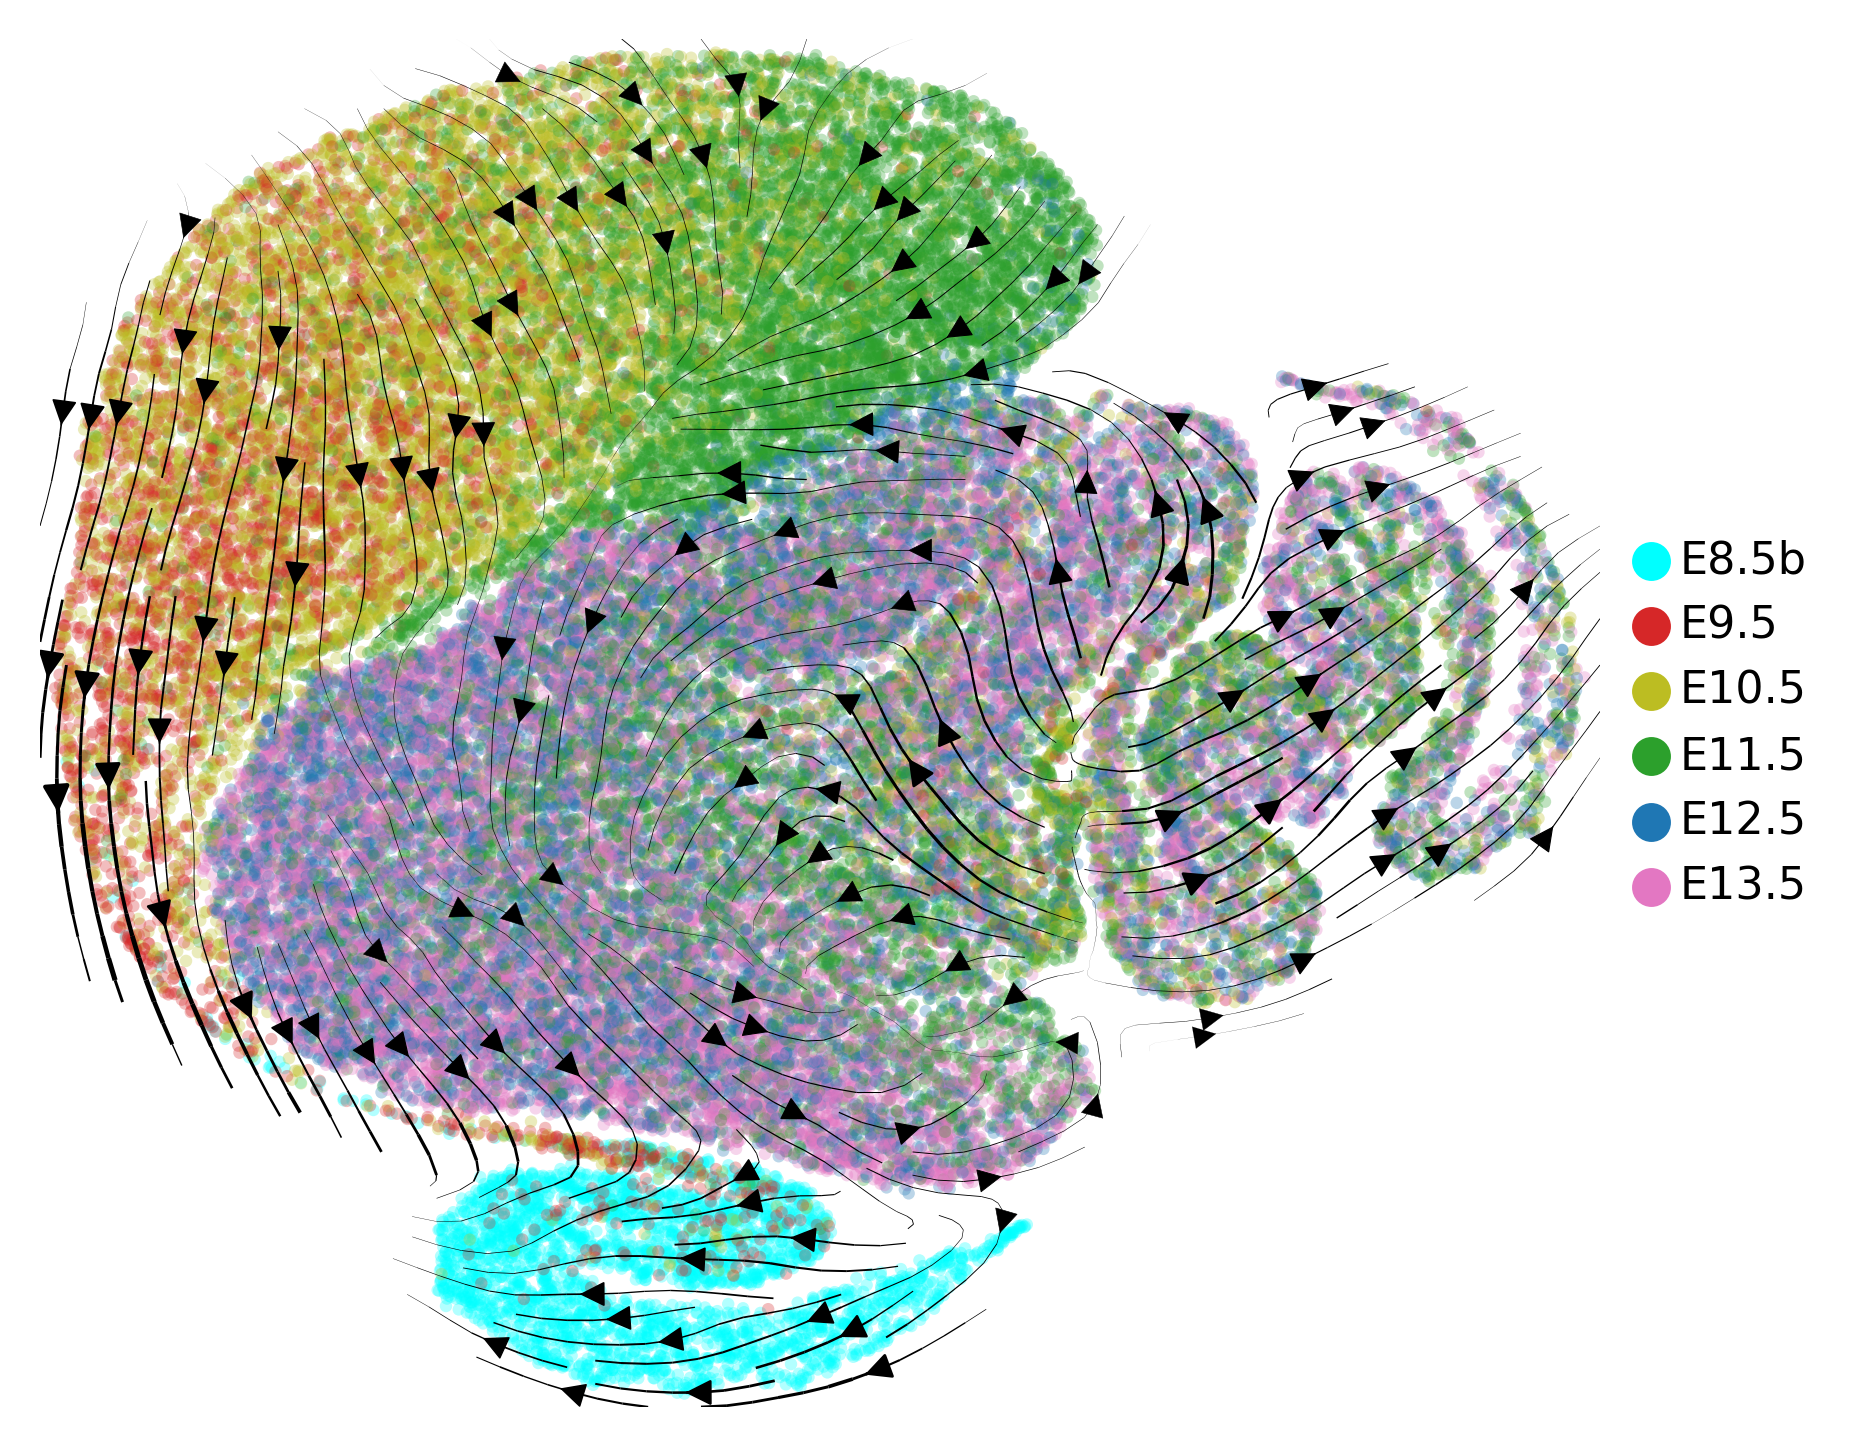

In [29]:
day_color_plate = {
'E6.5' :'red',
'E6.75':'yellow',
'E7'   :'green',
'E7.25':'blue',
'E7.5' :'tab:orange',
'E7.75':'tab:purple',
'E8'   :'tab:gray',
'E8.25':'tab:cyan',
'E8.5a' :'tab:brown',
'E8.5b' :'cyan',
'E9.5' :'tab:red',
'E10.5':'tab:olive',
'E11.5':'tab:green',
'E12.5':'tab:blue',
'E13.5':'tab:pink'
}

adata.obs['day'].cat.reorder_categories(["E8.5b", "E9.5", "E10.5", "E11.5", "E12.5", "E13.5"]
                                       )


scv.pl.velocity_embedding_stream(adata, 
                                 color = "day",
                                 legend_loc='right margin',
                                 legend_fontoutline = 2,
                                 figsize=(5, 4.5),
                                         legend_fontsize=8,
                                         linewidth=0.5, s=20,
                                 legend_fontweight = "normal",
                                 title = "",
                                 palette = day_color_plate,
                                 save=f"{save_result_path}/scVelo_{name}_day.png", dpi=200
                                 )
